# Defi EquiAlgo - modele corrige

Le notebook est constitué de deux grandes parties, d'abord l'analyse Fairlearn sur le modèle de base, puis notre model solution.

## Analyse Fairlearn sur model de base

Cette démarche est très fortement inspirée et adatée de l'exemple "Credit Loans Decisions" de la documentation de Fairlearn (https://fairlearn.org/v0.14/auto_examples/plot_credit_loan_decisions.html). 

Ce carnet implemente notre solution d'attenuation, avec un graphique du front de Pareto par balayage de la contrainte, et compare le modèle en production à notre modèle corrigé.

Maintenant que nous avons identifié les torts potentiellement causés, nous pouvons définir nos métriques d'équité. En plus de ces métriques, nous allons quantifier l'incertitude autour de chaque métrique en utilisant des fonctions qui calculent l'écart-type de chaque métrique à un niveau de confiance de alpha=0,95.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from fairlearn.metrics import (
    MetricFrame,
    count,
    selection_rate,
    false_negative_rate,
    false_positive_rate,
    equalized_odds_difference,
)


demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')

def compute_error_metric(metric_value, sample_size):
    """Compute standard error of a given metric based on the assumption of
    normal distribution.

    Parameters:
    metric_value: Value of the metric
    sample_size: Number of data points associated with the metric

    Returns:
    The standard error of the metric
    """
    metric_value = metric_value / sample_size
    return 1.96 * np.sqrt(metric_value * (1.0 - metric_value)) / np.sqrt(sample_size)

def false_negative_error(y_true, y_pred):
    """Compute the standard error for the false negative rate estimate."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return compute_error_metric(tp, fn + tp)

def false_positive_error(y_true, y_pred):
    """Compute the standard error for the false positive rate estimate."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return compute_error_metric(fp, fp + tn)

def accuracy_error(y_true, y_pred):
    """Compute the standard error for the precision estimate."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return compute_error_metric(tp + tn, tn + fp + fn + tp)

fairness_metrics = {
    "count": count,
    "accuracy": accuracy_score,
    "acurracy_error": accuracy_error,
    "selection_rate": selection_rate,
    "false_negative_rate": false_negative_rate,
    "false_negative_error": false_negative_error,
    "false_positive_rate": false_positive_rate,
    "false_positive_error": false_positive_error,
}

metrics_to_report = [
    "accuracy",
    "false_negative_rate",
    "false_positive_rate",
]

Pour calculer les métriques de performance désaggrégées, nous allons utiliser l'objet `MetricFrame` de la librairie Fairlearn. Nous allons fournir notre dictionnaire de métriques `fairness_metrics` ainsi que nos étiquettes de test `y_test` et les prédictions de test `y_pred`.

De plus, nous fournissons les caractéristiques sensibles `groupe_test` pour désaggréger les résultats de notre modèle.

                               candidats  taux_octroi  cote_r_moyenne
region_administrative                                                
Cote-Nord                           1178        0.263          27.325
Bas-Saint-Laurent                   1293        0.269          27.296
Gaspesie-Iles-de-la-Madeleine       1529        0.284          27.354
Montreal                            4001        0.483          27.988
Capitale-Nationale                  1999        0.484          27.984


array([[<Axes: title={'center': 'accuracy'}, xlabel='sensitive_feature_0'>,
        <Axes: title={'center': 'false_negative_rate'}, xlabel='sensitive_feature_0'>,
        <Axes: title={'center': 'false_positive_rate'}, xlabel='sensitive_feature_0'>]],
      dtype=object)

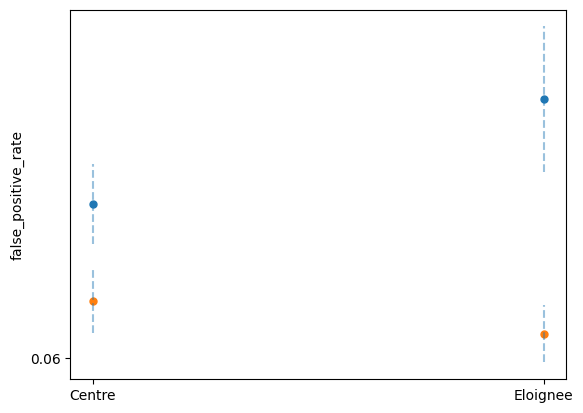

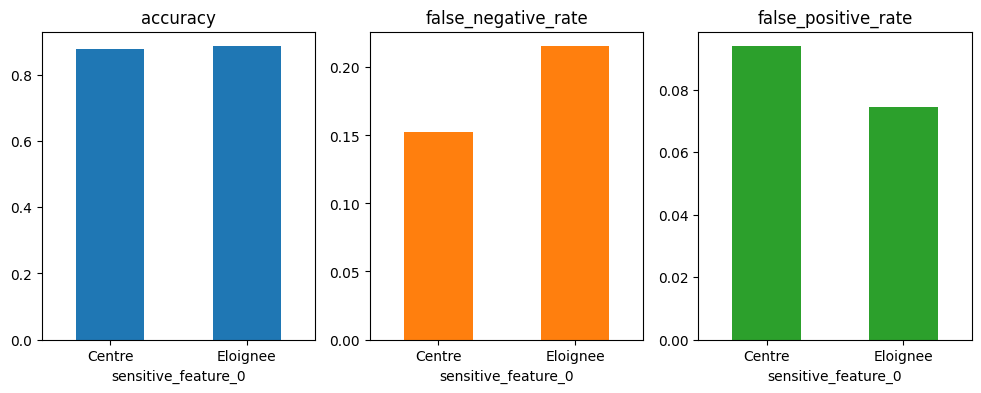

In [19]:
# Reprenons le modele de base pour le comparer.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')

# Les cinq regions administratives presentes dans le jeu de donnees.
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']

def groupe_region(df):
    """Regroupe les cinq regions en deux blocs : grands centres / regions eloignees."""
    return np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')

par_region = demandes.groupby('region_administrative').agg(
    candidats=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r_moyenne=('cote_r_equivalent', 'mean'),
).sort_values('taux_octroi')
print(par_region.round(3))

demandes['groupe'] = groupe_region(demandes)

CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']
def encoder(df_entrainement, df_cible):
    """Encode les colonnes categorielles et aligne les colonnes des deux tableaux.

    L'alignement (reindex) est important : si une categorie est absente d'un des
    deux jeux, get_dummies produit un nombre de colonnes different et le modele
    echoue - ou pire, apprend sur les mauvaises colonnes.
    """
    X = pd.get_dummies(
        df_entrainement.drop(columns=['id_candidat', 'decision_octroi', 'groupe'], errors='ignore'),
        columns=CATEGORIELLES,
    )
    Xc = pd.get_dummies(
        df_cible.drop(columns=['id_candidat', 'decision_octroi', 'groupe'], errors='ignore'),
        columns=CATEGORIELLES,
    ).reindex(columns=X.columns, fill_value=0)
    return X, Xc
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)
X_train, X_test = encoder(train, test)
y_train, y_test = train['decision_octroi'], test['decision_octroi']

modele = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

# Comparons maintenant avec nos metriques
groupe_test = groupe_region(test)

metricframe_unmitigated = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=groupe_test,
)

metricframe_unmitigated.by_group[metrics_to_report]

metricframe_unmitigated.difference()[metrics_to_report]

metricframe_unmitigated.overall[metrics_to_report]

def plot_group_metrics_with_error_bars(metricframe, metric, error_name):
    """Plot the disaggregated metric for each group with an associated
    error bar. Both metric and the error bar are provided as columns in the
    provided MetricFrame.

    Parameters
    ----------
    metricframe : MetricFrame
        The MetricFrame containing the metrics and their associated
        uncertainty quantification.
    metric : str
        The metric to plot
    error_name : str
        The associated standard error for each metric in metric

    Returns
    -------
    Matplotlib Plot of point estimates with error bars
    """
    grouped_metrics = metricframe.by_group
    point_estimates = grouped_metrics[metric]
    error_bars = grouped_metrics[error_name]
    lower_bounds = point_estimates - error_bars
    upper_bounds = point_estimates + error_bars

    x_axis_names = [str(name) for name in error_bars.index.to_flat_index().tolist()]
    plt.vlines(
        x_axis_names,
        lower_bounds,
        upper_bounds,
        linestyles="dashed",
        alpha=0.45,
    )
    plt.scatter(x_axis_names, point_estimates, s=25)
    plt.xticks(rotation=0)
    y_start, y_end = np.round(min(lower_bounds), decimals=2), np.round(
        max(upper_bounds), decimals=2
    )
    plt.yticks(np.arange(y_start, y_end, 0.05))
    plt.ylabel(metric)

plot_group_metrics_with_error_bars(
    metricframe_unmitigated, "false_negative_rate", "false_negative_error"
)

plot_group_metrics_with_error_bars(
    metricframe_unmitigated, "false_positive_rate", "false_positive_error"
)

metricframe_unmitigated.by_group[metrics_to_report].plot.bar(
    subplots=True, layout=[1, 3], figsize=[12, 4], legend=None, rot=0
)

Ici, une hypothèse clé est que nous supposons que les faux négatifs et les faux positifs ont tous les deux ont un impact négatif similaire sur les deux groupes.

Puisque le taux d'octroi de bourse est une contrainte fixe (entre 36% et 44%), il s'agit d'un cas "zero-sum game", c'est-à-dire qu'octroyer la bourse à une personne revient nécessairement à ne pas l'octroyer à une autre personne.

## Atténuation du biais du modèle de base

Nous venons d'identifier des disparités dans la performance du modèle selon la provenance des candidats. En particulier, nous avons trouvé que le modèle produit des taux de faux négatifs et de faux positifs siginificativement plus grands pour les candidats provenant des centres que pour ceux des candidats des régions éloignées. Dans ce contexte de décision d'octroi de bourse de mérite, cela signifie que le modèle sous-alloue des bourses aux candidats des régions éloignées qui auraient dû autrement la mériter, mais sur-alloue des bourses aux candidats des centres qui n'auraient pas autrement mérité la bourse. 

Dans cette section, nous allons implémenter deux stratégies pour atténuer les disparités de performance trouvées dans notre modèle de base. Les deux stratégies sont les suivantes:

 - Post-traitement: puisque nous avons une variable sensible (la région administrative), les décisions de notre classifieur peuvent être transformées pour satisfaire une contrainte d'équité donnée.

 - Réductions: dans cette approche, nous prenons une classe de modèle et créons une séquence de modèles qui optimise de manière itérative une contrainte d'équité donnée.

 Comparée à l'approche de post-traitement, la contrainte d'équité est satisfaite pendant l'entraînement du modèle plutôt qu'après.

# Atténutation post-traitement: ThresholdOptimizer

Dans la libraire Fairlearn, l'atténutation post-traitement est faite par l'algorithme `ThresholdOptimizer`, selon Hardt, Price, and Srebro. Le 
`ThresholdOptimizer` prend un modèle d'apprentissage automatique existant (possiblement déjà ajusté) dont les prédictions agissent en tant que fonction de score pour identifier des seuils distincts pour chaque groupe de caractéristiques sensibles. Le `ThresholdOptimizer` optimise une métrique d'objectif spécifique (dans notre cas le rappel, ce qui équivaut à 1 - taux de faux négatifs) sujet à une contrainte d'équité donnée (cote égalisée), ce qui donne une seuillée du modèle d'apprentissage automatique sous-jacent. 

Pour instancier notre `ThresholdOptimizer`, nous avons besoin de spécifier notre contrainte d'équité comme paramètre du modèle. Puisque les disparités de rappel et de faux positifs résultent tous les deux en des torts réels dans notre scénario, nous visons à utiliser la minimisation de la différence de cotes égalisées comme contrainte d'équité.

In [21]:
from fairlearn.postprocessing import ThresholdOptimizer

postprocess_est = ThresholdOptimizer(
    estimator=modele,
    constraints="equalized_odds",  # Optimize TPR and FPR simultaneously
    objective="accuracy_score",
    prefit=True,
    predict_method="predict_proba",
)

groupe_train = groupe_region(train)
postprocess_est.fit(X=X_train, y=y_train, sensitive_features=groupe_train)

postprocess_pred = postprocess_est.predict(X_test, sensitive_features=groupe_test)

postprocess_pred_proba = postprocess_est._pmf_predict(X_test, sensitive_features=groupe_test)

# Audit d'équité du modèle post-traité

def compare_metricframe_results(mframe_1, mframe_2, metrics, names):
    """Concatenate the results of two MetricFrames along a subset of metrics.

    Parameters
    ----------
    mframe_1: First MetricFrame for comparison
    mframe_2: Second MetricFrame for comparison
    metrics: The subset of metrics for comparison
    names: The names of the selected metrics

    Returns
    -------
    MetricFrame : MetricFrame
        The concatenation of the two MetricFrames, restricted to the metrics
        specified.

    """
    return pd.concat(
        [mframe_1.by_group[metrics], mframe_2.by_group[metrics]],
        keys=names,
        axis=1,
    )

accuracy_postprocess = accuracy_score(y_test, postprocess_pred)
eq_odds_postprocess = equalized_odds_difference(
    y_test, postprocess_pred, sensitive_features=groupe_test
)

metricframe_postprocess = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=postprocess_pred,
    sensitive_features=groupe_test,
)

metricframe_postprocess.overall[metrics_to_report]

metricframe_postprocess.difference()[metrics_to_report]

accuracy               0.000172
false_negative_rate    0.011841
false_positive_rate    0.024032
dtype: float64

Maintenant, comparons la performance de notre classifieur seuillé avec le modèle de base.

array([[<Axes: title={'center': 'accuracy'}, xlabel='sensitive_feature_0'>,
        <Axes: title={'center': 'false_negative_rate'}, xlabel='sensitive_feature_0'>,
        <Axes: title={'center': 'false_positive_rate'}, xlabel='sensitive_feature_0'>]],
      dtype=object)

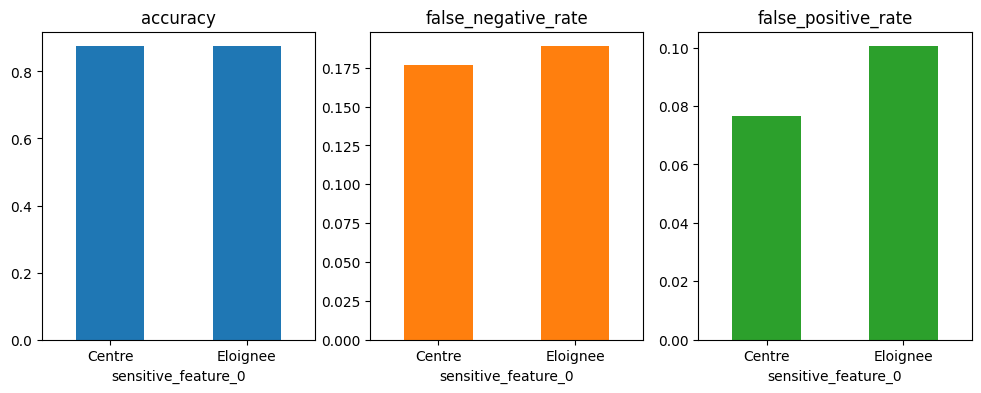

In [22]:

compare_metricframe_results(
    metricframe_unmitigated,
    metricframe_postprocess,
    metrics=metrics_to_report,
    names=["Unmitigated", "PostProcess"],
)

metricframe_postprocess.by_group[metrics_to_report].plot.bar(
    subplots=True, layout=[1, 3], figsize=[12, 4], legend=None, rot=0
)

On observe que l'algorithme de `ThresholdOptimizer` obtient une disparité bien plus basse entre les deux groupes par rapport au modèle de base.

## Model solution

Le comité suit une règle que l'on peut apprendre sur l'historique, mais cette règle contient deux biais : une **pénalité pour les régions éloignées** et un **avantage au revenu élevé**. Notre modèle apprend cette règle, **retire ces deux effets**, puis classe les candidats comme s'ils venaient tous d'un centre avec le même revenu. `decision_octroi` n'est donc pas la cible à reproduire : c'est l'étiquette d'un comité sous audit, et le jury évalue contre une référence indépendante.

Fonctionnement (`ModeleEquitable`, interface `.fit()` / `.predict()`): 
1. **Apprentissage (`fit`)** : régression logistique sur l'historique, avec la cote R, le log du revenu, les heures de travail, la première génération et le programme d'études. L'indicateur `eloignee` est un critère à part, ce qui isole la pénalité régionale du comité. Le code postal et la distance sont exclus : ce sont des proxys purs de la région (AUC ≈ 1,0).
2. **Score corrigé** : à la prédiction, on met `eloignee` à 0 et on remplace le revenu par la médiane. La région n'influence plus aucune décision.
3. **Décision (`predict`)** : les 40 % meilleurs scores reçoivent la bourse, ce qui respecte le budget imposé (36 à 44 %).
4. **Lisibilité (`lecture()`)** : les poids sont convertis en points de cote R. Pénalité régionale ≈ −1,4 point, revenu ≈ +0,9 point par doublement, heures ≈ +0,15 point par heure. Le modèle est explicable à un candidat comme au jury.

La région n'est pas directement retiré parce que le revenu, les heures, le code postal et la distance la portent encore : supprimer la colonne ne ferait passer l'écart de parité que de 0,188 à 0,181.

### Les leviers testés
| Paramètre | Rôle | Valeur retenue |
|---|---|---|
| `i_region` | pénalité régionale retirée (0 = gardée, 1 = retirée, >1 = sur-correction) | 1,0 |
| `i_revenu` | revenu neutralisé (0 = revenu réel, 1 = même revenu pour tous) | 1,0 |
| `i_heures` | heures neutralisées (0 = heures réelles, 1 = identiques) | 0 (critère de besoin, à confirmer par test) |
| `taux` | part de candidats qui reçoivent la bourse | 0,40 |
| `forme` | `lineaire`, `souple` (courbes) ou `arbres` | `lineaire` |

### Comment nous testons
Chaque solution est jugée sur deux axes : l'équité (écart de parité entre centres et régions éloignées, observable sur les 4 000 candidats) et l'utilité (exactitude indicative de la plateforme contre la référence). L'équité contre la référence elle-même n'est pas observable, donc la parité sert d'indicateur.
- **Un seul bouton à la fois** : chaque variante modifie un paramètre et est enregistrée dans un journal (`journal/journal_soumissions.csv`) avec ses taux par groupe. Les écarts de moins de 0,3 point sont traités comme du bruit. La version finale sera dans `predictions.csv`
- **Test local des formes** (`evaluer_formes`) : validation croisée sur les dossiers des centres, où la règle du comité n'a pas de pénalité régionale. Une forme plus souple n'est adoptée que si son gain dépasse 2 erreurs-types. Résultat : aucune ne bat le modèle linéaire (les arbres sont moins bons), donc nous gardons le plus lisible.
- **Comparaison avec fairlearn** : `ThresholdOptimizer` (seuils par groupe, exige la région au moment de la décision, budget non contrôlé) et `ExponentiatedGradient` (réentraînement sous contrainte). Ils sont comparés en parité démographique, car l'égalité des chances calculée sur une étiquette biaisée est un piège.
- **Front de Pareto** : on fait varier la contrainte d'équité de notre solution (`i_region`, `i_revenu`) et on trace l'écart de parité contre l'utilité, mesurée de deux façons : contre l'étiquette du comité (calcul local) et contre la référence indépendante (plateforme). Le modèle de départ (`baseline`) sert de repère et `a_base` est le réglage retenu.
- **Discipline** : le nombre de soumissions est limité et planifié à l'avance. Une variante n'est retenue que si elle est justifiable par l'audit, pas parce qu'elle gagne quelques dixièmes de point.

### Résultat principal
Reproduire le comité tel quel donne 88,6 % d'accord avec la référence et un écart de parité de 21,1 points. Le modèle corrigé donne 94,6 % et 0,2 point. S'éloigner de cette correction, dans un sens ou dans l'autre, dégrade les deux mesures.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

from modele_equitable import (JOURNAL, ModeleEquitable, archiver_non_retenues, balayage, balayage_local,
                              choisir, evaluer_formes, front_de_pareto, noter_lot, reinitialiser_journal)
from benchmark_fairlearn import comparer, piege_etiquette, soumettre_decisions

### Chargement des données

In [2]:
hist = pd.read_csv('data/donnees_demandes.csv')
cand = pd.read_csv('data/candidats_evaluation.csv')

### Le modèle

Lancement du premier jets de test avec le modèle.

In [3]:
m = ModeleEquitable().fit(hist, hist['decision_octroi'])
print(m.lecture())       # pénalité, revenu, heures en points de cote R (à comparer à l'audit : −1,4 / 0,9 / 0,15)

decisions = m.predict(cand)
print(f"taux d'octroi : {decisions.mean():.1%}")   # budget imposé : 36 à 44 %

                                    rapport_de_cotes  points_de_cote_R
cote_r_equivalent                              3.993              1.00
revenu (par doublement)                        3.438              0.89
heures_travail_semaine                         1.223              0.15
premiere_generation_universitaire              0.947             -0.04
eloignee                                       0.145             -1.40
programme_etudes_Genie                         1.054              0.04
programme_etudes_Sante                         1.059              0.04
programme_etudes_Sciences                      1.021              0.02
programme_etudes_Sciences sociales             1.009              0.01
taux d'octroi : 40.0%


### Test des formes

Une forme plus souple (`souple`, `arbres`) n'est adoptée que si le test local la préfère : validation croisée sur les dossiers des centres, gain retenu s'il dépasse 2 erreurs-types (colonne `significatif`).

In [4]:
tableau_formes = evaluer_formes(hist)   # significatif : True = gain réel, False = on reste simple
tableau_formes

,auc,perte_log,exactitude,gain,erreur_type,significatif
forme,,,,,,
lineaire,0.9528,0.2770,0.8784,NaN,NaN,NaN
souple,0.9529,0.2779,0.8789,-0.0009,0.0007,False
arbres,0.9515,0.2823,0.8757,-0.0053,0.0024,False


**Conclusion : le linéaire suffit.** Aucune forme plus souple ne reproduit mieux la règle du comité : `souple` et `arbres` ont une perte log plus élevée que le modèle linéaire (gain de −0,0009 et −0,0053), et `significatif` vaut `False` dans les deux cas. On garde donc le modèle linéaire, le plus lisible.

### Outils de soumissions

Ces outils permettent d'itérer rapidement afin d'observer ce qui fonctionne le mieux et optimiser le modèle en conséquence.

Le code de ces outils est dans `modele_equitable.py` (`soumettre`, `balayage`, `noter_lot`, `difference`, `choisir`, `reinitialiser_journal`, `archiver_non_retenues`).

In [5]:
reinitialiser_journal() 

variantes = {
    'a_base':            dict(),                        # région retirée, revenu neutralisé
    'b_revenu_garde':    dict(i_revenu=0),
    'c_revenu_moitie':   dict(i_revenu=0.5),
    'd_region_125':      dict(i_region=1.25),
    'e_region_075':      dict(i_region=0.75),
    'f_comite_tel_quel': dict(i_region=0, i_revenu=0),    # ancre : aucune correction
    'g_taux_38':         dict(taux=0.38),
    'h_taux_42':         dict(taux=0.42),
}
balayage(hist, cand, variantes, serie='jet1')

a_base: 4000 lignes, taux 40.0% (centre 39.9%, eloignee 40.1%) - OK
b_revenu_garde: 4000 lignes, taux 40.0% (centre 42.2%, eloignee 36.9%) - OK
c_revenu_moitie: 4000 lignes, taux 40.0% (centre 41.2%, eloignee 38.2%) - OK
d_region_125: 4000 lignes, taux 40.0% (centre 38.1%, eloignee 42.8%) - OK
e_region_075: 4000 lignes, taux 40.0% (centre 41.7%, eloignee 37.5%) - OK
f_comite_tel_quel: 4000 lignes, taux 40.0% (centre 48.6%, eloignee 27.5%) - OK
g_taux_38: 4000 lignes, taux 38.0% (centre 37.8%, eloignee 38.3%) - OK
h_taux_42: 4000 lignes, taux 42.0% (centre 42.1%, eloignee 41.8%) - OK


,nom,serie,heure,i_region,i_revenu,i_heures,forme,taux_cible,C,taux,taux_centre,taux_eloignee,accuracy,f1
0,a_base,jet1,2026-10-04 09:05,1.00,1.0,0.0,lineaire,0.40,100.0,0.40,0.399,0.401,NaN,NaN
1,b_revenu_garde,jet1,2026-10-04 09:05,1.00,0.0,0.0,lineaire,0.40,100.0,0.40,0.422,0.369,NaN,NaN
2,c_revenu_moitie,jet1,2026-10-04 09:05,1.00,0.5,0.0,lineaire,0.40,100.0,0.40,0.412,0.382,NaN,NaN
3,d_region_125,jet1,2026-10-04 09:05,1.25,1.0,0.0,lineaire,0.40,100.0,0.40,0.381,0.428,NaN,NaN
4,e_region_075,jet1,2026-10-04 09:05,0.75,1.0,0.0,lineaire,0.40,100.0,0.40,0.417,0.375,NaN,NaN
5,f_comite_tel_quel,jet1,2026-10-04 09:05,0.00,0.0,0.0,lineaire,0.40,100.0,0.40,0.486,0.275,NaN,NaN
6,g_taux_38,jet1,2026-10-04 09:05,1.00,1.0,0.0,lineaire,0.38,100.0,0.38,0.378,0.383,NaN,NaN
7,h_taux_42,jet1,2026-10-04 09:05,1.00,1.0,0.0,lineaire,0.42,100.0,0.42,0.421,0.418,NaN,NaN


On enregistre ensuite les résultats des soumissions dans le journal :

In [6]:
# Chiffres relevés sur HxBuddy : (exactitude, F1) affichés par la plateforme pour chaque soumission
journal = noter_lot({
    'a_base':            (94.58, 94.35),
    'b_revenu_garde':    (92.58, 92.26),
    'c_revenu_moitie':   (94.23, 93.98),
    'd_region_125':      (94.18, 93.93),
    'e_region_075':      (94.43, 94.19),
    'f_comite_tel_quel': (88.63, 88.15),
    'g_taux_38':         (94.33, 94.03),
    'h_taux_42':         (92.58, 92.39),
})

comparatif = journal[['nom', 'i_region', 'i_revenu', 'taux_cible', 'accuracy', 'f1']].copy()
comparatif['ecart_parite'] = (journal['taux_centre'] - journal['taux_eloignee']).round(3)
comparatif = comparatif.rename(columns={'accuracy': 'exactitude_plateforme', 'f1': 'f1_plateforme'})
comparatif.set_index('nom')

,i_region,i_revenu,taux_cible,exactitude_plateforme,f1_plateforme,ecart_parite
nom,,,,,,
a_base,1.00,1.0,0.40,94.58,94.35,-0.002
b_revenu_garde,1.00,0.0,0.40,92.58,92.26,0.053
c_revenu_moitie,1.00,0.5,0.40,94.23,93.98,0.030
d_region_125,1.25,1.0,0.40,94.18,93.93,-0.047
e_region_075,0.75,1.0,0.40,94.43,94.19,0.042
f_comite_tel_quel,0.00,0.0,0.40,88.63,88.15,0.211
g_taux_38,1.00,1.0,0.38,94.33,94.03,-0.005
h_taux_42,1.00,1.0,0.42,92.58,92.39,0.003


### Comparaison de ModeleEquitable avec les deux outils fairlearn

- ThresholdOptimizer : garde un modele deja entraine et change le SEUIL de chaque groupe. Cet optimizer de Fairlearn est un outil de post-traitement qui ajuste les décisions d'un modèle d'intelligence artificielle déjà entraîné pour corriger les discriminations et assurer l'équité entre différents groupes de personnes.
- ExponentiatedGradient : reentraine le modele sous une contrainte d'equite (borne de parite `difference_bound`).

Role dans le projet : points de comparaison pour la presentation et le front de Pareto, pas le modele principal. Voir modele_equitable.py pour le modele principal.

On peut maintenant lancer les fonctions du benchmark (utilise `benchmark_fairlearn.py`):

In [7]:
# 1. Calculer toutes les méthodes d'un coup (bornes = le bouton du front de Pareto)
tab, dec = comparer(hist, cand, bornes=(0.005, 0.02, 0.05, 0.1))
print(tab)

# 2. Pour l'audit : le piège de l'égalité des chances sur l'étiquette biaisée
print(piege_etiquette(hist))

# 3. Soumettre celles qui respectent le budget
for nom in tab.index[tab['budget_ok'] & tab.index.str.startswith('fl_')]:
    soumettre_decisions(dec[nom], cand, nom, serie='fairlearn')

                          taux  taux_centre  taux_eloignee  ecart_parite  \
methode                                                                    
a_base                   0.400        0.399          0.401        -0.002   
fl_seuils_parite         0.401        0.400          0.402        -0.003   
fl_seuils_eo_biaisee     0.407        0.474          0.310         0.164   
fl_eg_eo_biaisee         0.402        0.462          0.314         0.148   
fl_eg_parite_borne0.005  0.411        0.409          0.413        -0.003   
fl_eg_parite_borne0.02   0.405        0.417          0.388         0.028   
fl_eg_parite_borne0.05   0.404        0.433          0.362         0.071   
fl_eg_parite_borne0.1    0.404        0.445          0.343         0.101   

                         accord_avec_a_base  budget_ok  
methode                                                 
a_base                                1.000       True  
fl_seuils_parite                      0.918       True  
fl_seuils_e

### Lecture

Pour TesholdOptimizer :
- l'accord avec a_base est de 0.918
- l'écart de partité reste le même si on prend en compte une marge d'erreur (-0.002 à -0.003)

Pour ExponentiatedGradient :
- l'écart de parité passe de -0.002 à 0.028, 0.071 puis 0.101
- La borne porte sur l'écart de chaque groupe à la moyenne. L'écart entre groupes vaut donc au plus environ 1,7 fois la borne.

À parité égale (≈ 0), fairlearn n'apporte pas de gain démontré. Il garde les proxys intacts, comme le montre l'écart de 0,101 quand la contrainte est relâchée. Il impose soit la région à la décision, soit un classifieur aléatoire. Sous égalité des chances mesurée sur l'étiquette du comité, il aggrave la parité. Nous retenons a_base.

### Front de Pareto


On a besoin du modèle départ pour construire Pareto :

In [8]:
def modele_de_depart(hist, cand):
    """Reproduit le modele en production de baseline_model.ipynb : foret aleatoire sur TOUTES les colonnes
    (region et code postal compris). Point de depart du front de Pareto : aucune correction."""
    categorielles = ['programme_etudes', 'region_administrative', 'code_postal_3']
    colonnes = [c for c in hist.columns if c not in ('id_candidat', 'decision_octroi', 'groupe')]
    X = pd.get_dummies(hist[colonnes], columns=categorielles)
    Xc = pd.get_dummies(cand[colonnes], columns=categorielles).reindex(columns=X.columns, fill_value=0)
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
    rf.fit(X, hist['decision_octroi'])
    return rf.predict(Xc).astype(int)

In [15]:
dec_base = modele_de_depart(hist, cand)
soumettre_decisions(dec_base, cand, 'baseline', serie='baseline');   # soumissions/baseline.csv + journal
# À activer quand HxBuddy revient (chiffres relevés sur HxBuddy) :
# noter_lot({'baseline': (acc, f1)})

baseline: 4000 lignes, taux 39.1% (centre 46.8%, eloignee 27.8%) - OK


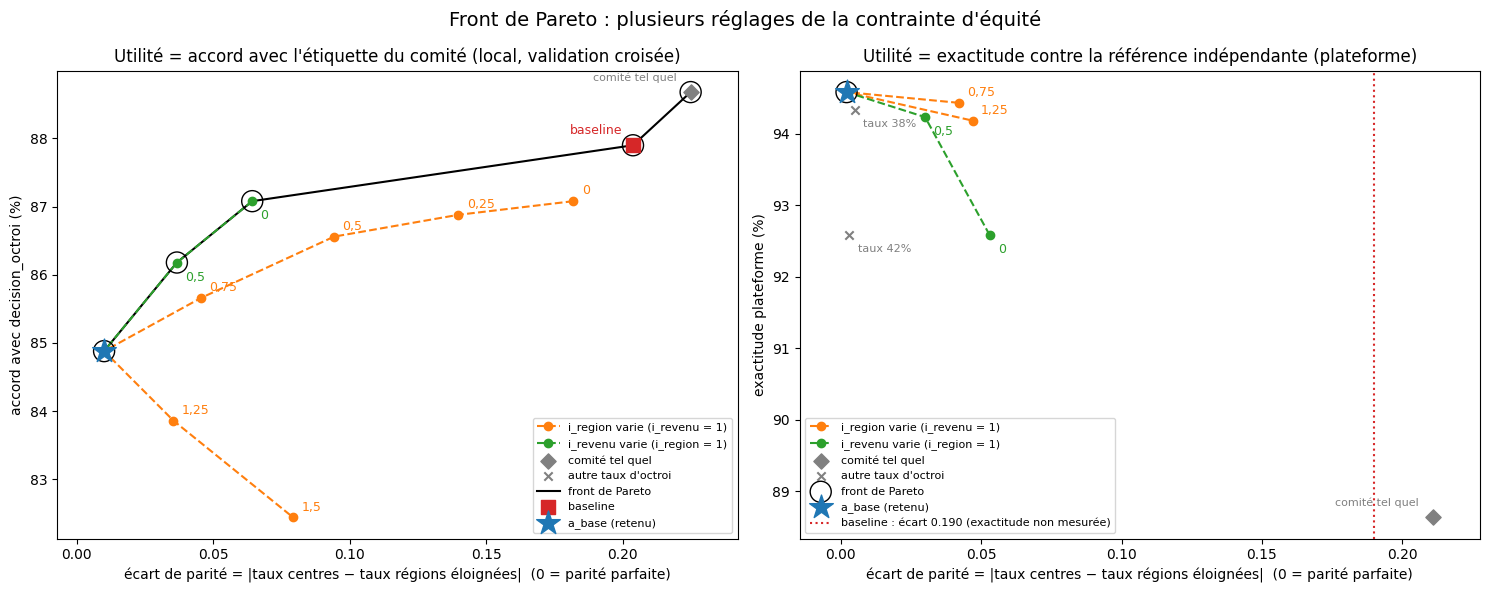

In [16]:
# Front de Pareto : plusieurs réglages de la contrainte d'équité (i_region, i_revenu), comparés au modèle de départ
reglages = {'comité tel quel': dict(i_region=0, i_revenu=0)}
reglages.update({f'i_region={r:g}': dict(i_region=r) for r in (0, 0.25, 0.5, 0.75, 1, 1.25, 1.5)})
reglages.update({f'i_revenu={v:g}': dict(i_revenu=v) for v in (0, 0.5)})
local = balayage_local(hist, reglages, depart=modele_de_depart)       # mesure locale, sans la plateforme
local['utilite'] = local['accord_comite'] * 100

j = pd.read_csv(JOURNAL).groupby('nom', sort=False).last()            # exactitude relevée sur HxBuddy (4 000 candidats)
j['ecart_parite'] = (j['taux_centre'] - j['taux_eloignee']).abs()
j['utilite'] = j['accuracy']
mesures = j[j['i_region'].notna() & j['utilite'].notna()]             # nos réglages notés sur la plateforme
base = j.loc['baseline']


def virgule(x):
    return f'{x:g}'.replace('.', ',')


def tracer_reglages(ax, d):
    """Nos réglages : i_region varie (orange), i_revenu varie (vert), comité tel quel (gris), autres taux (croix)."""
    budget = d['taux_cible'] == 0.40
    region = d[budget & (d['i_revenu'] == 1)].sort_values('i_region')
    revenu = d[budget & (d['i_region'] == 1)].sort_values('i_revenu')
    ancre = d[budget & (d['i_region'] == 0) & (d['i_revenu'] == 0)]
    autres = d[d['taux_cible'].notna() & ~budget]
    ax.plot(region['ecart_parite'], region['utilite'], 'o--', color='tab:orange', zorder=2,
            label='i_region varie (i_revenu = 1)')
    ax.plot(revenu['ecart_parite'], revenu['utilite'], 'o--', color='tab:green', zorder=2,
            label='i_revenu varie (i_region = 1)')
    ax.scatter(ancre['ecart_parite'], ancre['utilite'], marker='D', s=60, color='gray', zorder=3, label='comité tel quel')
    ax.scatter(autres['ecart_parite'], autres['utilite'], marker='x', color='gray', zorder=3, label="autre taux d'octroi")
    for r in region.itertuples():                                       # valeur du réglage, dans la couleur de sa courbe
        if not (r.i_region == 1 and r.i_revenu == 1):                  # a_base a sa propre étiquette
            ax.annotate(virgule(r.i_region), (r.ecart_parite, r.utilite), textcoords='offset points',
                        xytext=(6, 5), fontsize=9, color='tab:orange')
    for r in revenu.itertuples():
        if not (r.i_region == 1 and r.i_revenu == 1):
            ax.annotate(virgule(r.i_revenu), (r.ecart_parite, r.utilite), textcoords='offset points',
                        xytext=(6, -13), fontsize=9, color='tab:green')
    for r in ancre.itertuples():
        ax.annotate('comité tel quel', (r.ecart_parite, r.utilite), textcoords='offset points', xytext=(-10, 8),
                    ha='right', fontsize=8, color='gray')
    for r in autres.itertuples():
        ax.annotate(f'taux {r.taux_cible:.0%}', (r.ecart_parite, r.utilite), textcoords='offset points',
                    xytext=(6, -12), fontsize=8, color='gray')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Front de Pareto : plusieurs réglages de la contrainte d'équité", fontsize=14)

# --- Gauche : contre l'étiquette du comité (calcul local, validation croisée) ---
tracer_reglages(ax1, local)
a = local[(local['i_region'] == 1) & (local['i_revenu'] == 1) & (local['taux_cible'] == 0.40)].iloc[0]
b = local.loc['baseline']
front = local[front_de_pareto(local['ecart_parite'], local['utilite'])].sort_values('ecart_parite')
ax1.plot(front['ecart_parite'], front['utilite'], '-', color='black', lw=1.5, zorder=1, label='front de Pareto')
ax1.scatter(front['ecart_parite'], front['utilite'], s=230, facecolors='none', edgecolors='black', zorder=4)
ax1.scatter(b['ecart_parite'], b['utilite'], marker='s', s=90, color='tab:red', zorder=5, label='baseline')
ax1.annotate('baseline', (b['ecart_parite'], b['utilite']), textcoords='offset points', xytext=(-8, 8),
             ha='right', fontsize=9, color='tab:red')
ax1.scatter(a['ecart_parite'], a['utilite'], marker='*', s=320, color='tab:blue', zorder=5, label='a_base (retenu)')
ax1.set_title("Utilité = accord avec l'étiquette du comité (local, validation croisée)")
ax1.set_ylabel('accord avec decision_octroi (%)')
ax1.legend(loc='lower right', fontsize=8)

# --- Droite : contre la référence indépendante (plateforme HxBuddy) ---
tracer_reglages(ax2, mesures)
a = j.loc['a_base']
front = mesures[front_de_pareto(mesures['ecart_parite'], mesures['utilite'])]
ax2.scatter(front['ecart_parite'], front['utilite'], s=230, facecolors='none', edgecolors='black', zorder=4,
            label='front de Pareto')
ax2.scatter(a['ecart_parite'], a['utilite'], marker='*', s=320, color='tab:blue', zorder=5, label='a_base (retenu)')
if pd.notna(base['utilite']):                                          # baseline noté : point rouge + flèche
    ax2.scatter(base['ecart_parite'], base['utilite'], marker='s', s=90, color='tab:red', zorder=5, label='baseline')
    ax2.annotate('', xy=(a['ecart_parite'], a['utilite']), xytext=(base['ecart_parite'], base['utilite']),
                 arrowprops=dict(arrowstyle='->', lw=2, color='gray'), zorder=1)
else:                                                                  # pas encore noté : l'écart de parité est connu
    ax2.axvline(base['ecart_parite'], color='tab:red', ls=':', zorder=1,
                label=f"baseline : écart {base['ecart_parite']:.3f} (exactitude non mesurée)")
ax2.set_title('Utilité = exactitude contre la référence indépendante (plateforme)')
ax2.set_ylabel('exactitude plateforme (%)')
ax2.legend(loc='lower left', fontsize=8)

for ax in (ax1, ax2):
    ax.set_xlabel('écart de parité = |taux centres − taux régions éloignées|  (0 = parité parfaite)')
    ax.margins(x=0.08)
plt.tight_layout()
plt.show()

### Lecture

- la courbe orange varie i_region, la part de pénalité régionale du comité qu'on retire (de 0 à 1,5) ;
- la courbe verte varie i_revenu, la part de l'avantage au revenu qu'on retire ;
- l'axe horizontal est l'écart de parité : plus on est à gauche, plus c'est équitable ;
- l'axe vertical est l'utilité. Elle est mesurée de deux façons, une par panneau.

Panneau de gauche :
- Augmenter le poids de l'importance de la région fait baisser les performances
- La variation du revenu et des heures permet d'améliorer le modèle de base

Panneau de droite :
- `a_base` est en haut à gauche : 94,58 % pour un écart de 0,002 ;
- le comité tel quel est à 88,63 %, donc corriger gagne environ 6 points ;
- s'éloigner de  `a_base` dégrade : i_revenu 0 donne 92,58 %, i_region 0,75 donne 94,43 % mais avec un écart de 0,042.

### Choix final

Le livrable est `predictions.csv` : on y copie la soumission retenue, puis on vérifie son format et son budget.

In [11]:
choisir('a_base')

pred = pd.read_csv('predictions.csv')
assert list(pred.columns) == ['id_candidat', 'decision_octroi'], 'colonnes inattendues'
assert len(pred) == len(cand) and pred['id_candidat'].is_unique, 'lignes manquantes ou identifiants dupliqués'
assert set(pred['id_candidat']) == set(cand['id_candidat']), 'identifiants différents de candidats_evaluation.csv'
assert set(pred['decision_octroi']) <= {0, 1}, 'valeurs hors {0, 1}'
assert 0.36 <= pred['decision_octroi'].mean() <= 0.44, 'HORS BUDGET'
print(f"predictions.csv valide : {len(pred)} lignes, taux d'octroi {pred['decision_octroi'].mean():.1%}")

predictions.csv = a_base
predictions.csv valide : 4000 lignes, taux d'octroi 40.0%


### Rangement des fichiers

Seules `a_base` (copiée dans `predictions.csv`) et `baseline` restent dans `soumissions/`. Les autres soumissions sont rangées dans `journal/anciennes_versions/` ; le journal et ses archives sont dans `journal/`. Rien n'est supprimé.

In [12]:
archiver_non_retenues();

14 soumissions non retenues rangees dans journal/anciennes_versions/ ; retenues : a_base, baseline
